In [1]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.1-pro-preview", 
    contents="Hello from my Jupyter notebook!"
)

print(response.text)

Hello right back! 🐍✨

It's great to connect directly from your Jupyter environment. What are we working on today? Whether it's data analysis, machine learning, debugging some Python code, or just testing an API, I'm here to help. 

Let me know what you need!


In [2]:
import sys
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instan

Torch version: 2.2.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torch CUDA: 11.8


In [3]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import requests
import pandas as pd
import re
from jiwer import wer, cer

## Download Dataset

In [4]:
import os

data_dir = "../camera_captured_data"

pages = [
    "8_camera",
    "8_degraded",
    "9_camera",
    "619_camera",
    "9_degraded_1",
    "9_degraded_2",
    "9_degraded_3",
    "9_degraded_4"
    
]

for p in pages:
    image_path = os.path.join(data_dir, f"{p}.jpg")
    print(image_path, ":", os.path.exists(image_path))

../camera_captured_data\8_camera.jpg : True
../camera_captured_data\8_degraded.jpg : True
../camera_captured_data\9_camera.jpg : True
../camera_captured_data\619_camera.jpg : True
../camera_captured_data\9_degraded_1.jpg : True
../camera_captured_data\9_degraded_2.jpg : True
../camera_captured_data\9_degraded_3.jpg : True
../camera_captured_data\9_degraded_4.jpg : True


In [5]:
import os

output_dir = "Output_camera/experiment_files"
os.makedirs(output_dir, exist_ok=True)
output_dir_2 = "Output_camera/experiment_graphs"
os.makedirs(output_dir_2, exist_ok=True)

In [6]:
prompt_text_0 = "Extract all text from this image exactly as written. Preserve line breaks."

In [7]:
prompt_text_2 = """
You are an OCR specialist.

Extract every visible character from this image exactly as it appears.

Return plain text only. Preserve the original reading order, line breaks, paragraph breaks, headings, punctuation, capitalization, spelling, abbreviations, umlauts, ß, Roman numerals, page numbers, and hyphenation exactly as printed.

Do not correct spelling or grammar. Do not modernize, normalize, translate, summarize, explain, or infer missing text. Do not merge words that are split by line-ending hyphens.

If any character or word cannot be read with confidence, write [illegible] exactly at that position instead of guessing.

Do not include any #, comments, Markdown, labels, or additional text. Return only the transcription.
"""

In [8]:
import os
from google import genai
from google.genai import types


def run_ocr_one_image(image_path, prompt_text):
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    response = client.models.generate_content(
        model="gemini-3.1-pro-preview",
        contents=[
            prompt_text,
            types.Part.from_bytes(
                data=image_bytes,
                mime_type="image/jpeg"
            )
        ]
    )

    return response.text

In [10]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(data_dir, f"{p}.jpg")
    output_path = os.path.join(output_dir, f"{p}.txt")

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_2
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 8_camera
Vorwort.

Das Jahr 1885 brachte die erste Fortsetzung des K. Ruprecht mit dem zweiten
Bande von dessen Regierung, dem fünften der ganzen Reihe. Im Jahr 1887 wurde
die dritte Abtheilung der Zeit K. Sigmund's ausgegeben, der neunte Band der Reichs-
tagsakten. Jetzt nach einem Jahre können wir bereits den sechsten Band mittheilen,
welcher zugleich der dritte und Schlußband K. Ruprecht's ist. Hiemit schließt sich die
Lücke, welche in der Regierung dieses Königs noch auszufüllen war, und die sämmt-
lichen bisher erschienenen neun Bände bilden eine ununterbrochene Kette. Mit dem
zehnten Bande, dessen Ausgabe das nächste sein wird, soll dann auch die Periode K.
Sigmund's zu ihrem Ende kommen.

I. Bearbeitung des vorliegenden Bandes.

Die Leitung des Unternehmens ruht wie bisher in der Hand H. v. Sybel's. Von
früheren Mitarbeitern des Bandes, welche bei den Vorarbeiten überhaupt sowie ins-
besondere bei der Anfertigung von Regesten Auszügen und Abschriften thätig waren,
sind zu 

In [11]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [12]:
gold_pages = {
    "8_camera": 8,
    "8_degraded": 8,
    "9_camera": 9,
    "619_camera": 619,
    "9_degraded_1": 9,
    "9_degraded_2": 9,
    "9_degraded_3": 9,
    "9_degraded_4": 9
}

results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for p in pages:
    print(f"Evaluating page {p}...")

    # Ground-truth page number
    gt_page = gold_pages[p]

    # Load ground truth
    gold_url = f"{gold_base}{gt_page}.txt"
    gold_text = requests.get(gold_url).text

    # Load PaddleOCR output
    pred_path = os.path.join(output_dir, f"{p}.txt")
    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    # Compute metrics
    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 8_camera...
Evaluating page 8_degraded...
Evaluating page 9_camera...
Evaluating page 619_camera...
Evaluating page 9_degraded_1...
Evaluating page 9_degraded_2...
Evaluating page 9_degraded_3...
Evaluating page 9_degraded_4...


In [13]:
print("=== Experiment 1 Results: PaddleOCR ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: PaddleOCR ===


,page,WER,CER
0,8_camera,0.014888,0.002232
1,8_degraded,0.014888,0.002232
2,9_camera,0.008897,0.001893
3,619_camera,0.028024,0.008812
4,9_degraded_1,0.007117,0.001622
5,9_degraded_2,0.010676,0.002163
6,9_degraded_3,0.012456,0.002434
7,9_degraded_4,0.012456,0.002434


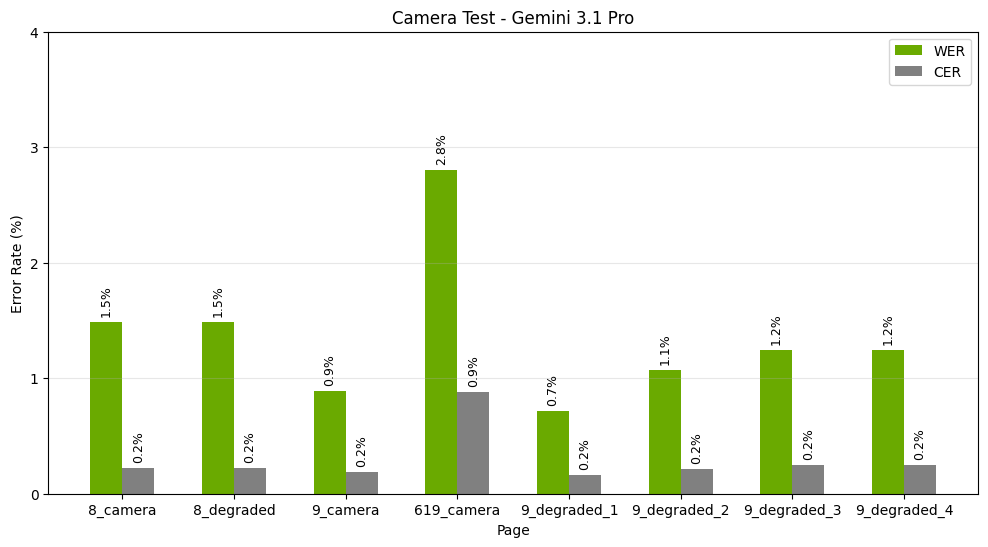

In [17]:
# With vector graphics
import numpy as np
import matplotlib.pyplot as plt
import os

# Reduce spacing between page groups
x = np.arange(len(df_exp1)) * 0.7

# Width of individual bars
width = 0.20

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(12, 6))

# WER bars
bars1 = plt.bar(
    x - width/2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

# CER bars
bars2 = plt.bar(
    x + width/2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

# WER values
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

# CER values
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_exp1["page"])

plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Camera Test - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 4)
plt.yticks(np.arange(0, 4.1, 1))

os.makedirs(output_dir_2, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_2,
        "experiment_1_wer_cer_by_page_camera_Gemini_3.1_Pro.pdf"
    ),
    bbox_inches="tight"
)

plt.show()